In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#Loading the Excel Dataset
df=pd.read_excel("Dataset for Data Analytics (2).xlsx")
print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [5]:
#Check Dataset Shape
print(df.shape)

(1200, 14)


In [6]:
#Check Column Names
print(df.columns)

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')


In [7]:
#Check Data Types
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [8]:
#Check Missing Values
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [9]:
#Fill Missing Values
df["CouponCode"] = df["CouponCode"].fillna("Unknown")

In [10]:
#Summary Statistics
print(df.describe())

                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558


In [11]:
#Calculate Individual Statistics
print(df["TotalPrice"].mean())

1053.9683


In [12]:
print(df["TotalPrice"].median())

823.615


In [13]:
print(df["TotalPrice"].count())
print(df["TotalPrice"].max())
print(df["TotalPrice"].min())

1200
3456.4
11.39


In [14]:
##Finding Top Products by Total Price

In [15]:
top_products = df.groupby("Product")["TotalPrice"].sum()

print(top_products)

Product
Chair      195620.11
Desk       167459.93
Laptop     192126.56
Monitor    175651.41
Phone      151722.39
Printer    195612.61
Tablet     186568.95
Name: TotalPrice, dtype: float64


In [16]:
#sorting Highest Revenue products

In [17]:
top_products = top_products.sort_values(ascending=False)

print(top_products)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


In [18]:
#Most used Payment Method

In [19]:
print(df["PaymentMethod"].value_counts())

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


In [20]:
#Order Status Analysis

In [21]:
print(df["OrderStatus"].value_counts())

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


In [22]:
#Convert Date Column
df["Date"] = pd.to_datetime(df["Date"])

In [23]:
#Extract Month
df["Month"] = df["Date"].dt.month

In [24]:
#Monthly Sales Trend
monthly_sales = df.groupby("Month")["TotalPrice"].sum()

print(monthly_sales)

Month
1     124313.23
2     112344.78
3     123840.93
4     109186.05
5     135142.59
6     170616.13
7      85784.64
8      86343.21
9      69321.65
10     89834.82
11     75493.43
12     82540.50
Name: TotalPrice, dtype: float64


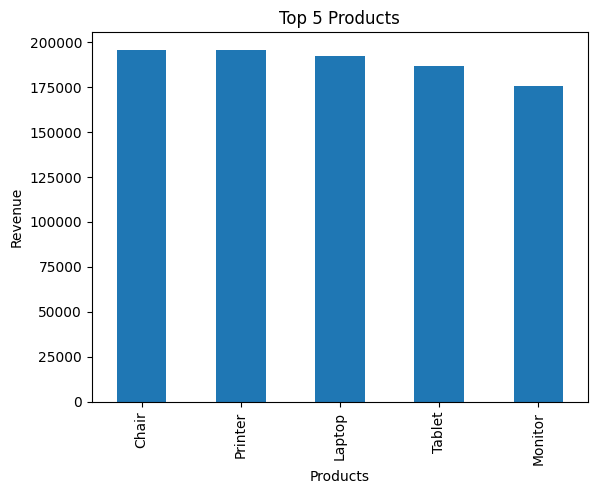

In [25]:
#Visualize Top 5 Products
top_products.head(5).plot(kind="bar")

plt.title("Top 5 Products")
plt.xlabel("Products")
plt.ylabel("Revenue")

plt.show()

Explanation: The bar chart shows the top 5 products generating the highest revenue. Products with taller bars contribute more to overall business sales. This analysis helps identify the most profitable products.

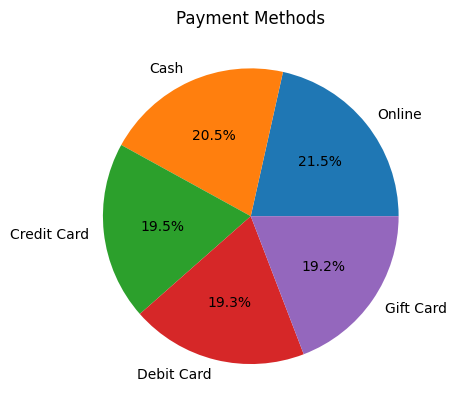

In [26]:
#Payment Method Distribution
df["PaymentMethod"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Payment Methods")

plt.show()

Explanation: The pie chart represents the distribution of payment methods used by customers. It helps understand customer payment preferences and which payment mode is most commonly used.

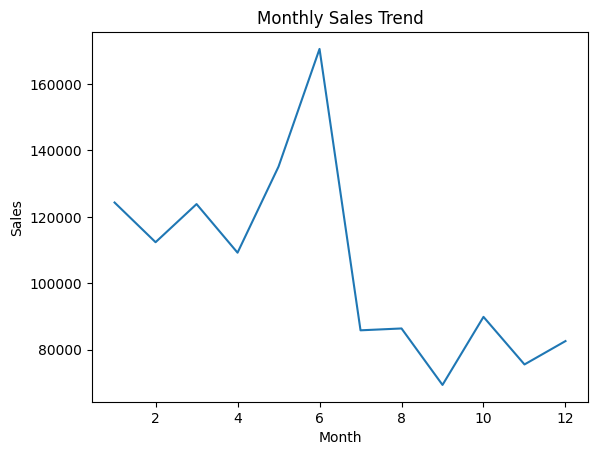

In [27]:
#Visualize Monthly Sales Trend
monthly_sales.plot(kind="line")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

Explanation: The line chart displays monthly sales trends over time. It helps identify growth patterns, seasonal fluctuations, and months with higher sales performance

In [28]:
#Detecting Outliers in Total Price
print(df["TotalPrice"].describe())

count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64


In [29]:
#Correlation Analysis
print(df.corr(numeric_only=True))

             Quantity  UnitPrice  ItemsInCart  TotalPrice     Month
Quantity     1.000000   0.014553     0.650061    0.615251 -0.015118
UnitPrice    0.014553   1.000000     0.000602    0.717081 -0.026130
ItemsInCart  0.650061   0.000602     1.000000    0.392540 -0.018151
TotalPrice   0.615251   0.717081     0.392540    1.000000 -0.027734
Month       -0.015118  -0.026130    -0.018151   -0.027734  1.000000


In [30]:
#save the cleaned dataset
df.to_excel("cleaned_dataset.xlsx", index=False)

Conclusion
The EDA process helped uncover important business insights from the dataset. The analysis identified top-performing products, customer payment preferences, and monthly sales trends. These insights can help businesses make data-driven decisions and improve future strategies.
